In [4]:
# Compare forecasting models for yield and consumption
# Models: Holt, ARIMA, Prophet

import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Load dataset
Forecast_Model ='https://raw.githubusercontent.com/Umangi123/Final-Year-Project_w1954804/refs/heads/main/data/Forecast%20Model.csv'
df = pd.read_csv(Forecast_Model)

df.head()

,Year,Total_Consumption_MT,Net_Harvested_ha,Annual_Yield_kg_per_ha
0,2004,1954122.214,3903,3250.576480
1,2005,2027717.357,5672,2989.245416
2,2006,2052133.601,3233,2974.017940
3,2007,2111551.837,3948,3472.644377
4,2008,2161339.933,7067,3378.236876


In [5]:
# Sort the dataset by year
df = df.sort_values("Year")

# Set the year column as the index
df["Year"] = df["Year"].astype(int)
df = df.set_index("Year")

In [6]:
# Split data (last 3 years as test set)
train = df.iloc[:-3]
test = df.iloc[-3:]
test_years = test.index.tolist()
print("Test years:", test.index.tolist())

Test years: [2021, 2022, 2023]


In [7]:
# Holt Exponential Smoothing Models

# Train Holt model for yield forecasting
holt_yield_model = ExponentialSmoothing(
    train["Annual_Yield_kg_per_ha"],
    trend="add",
    seasonal=None
).fit()

# Train Holt model for consumption forecasting
holt_cons_model = ExponentialSmoothing(
    train["Total_Consumption_MT"],
    trend="add",
    seasonal=None
).fit()

# Predict values for test period
holt_yield_pred = holt_yield_model.forecast(len(test))
holt_cons_pred = holt_cons_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

In [8]:
# ARIMA Models

# Train ARIMA models (1,1,1) for both yield and consumption
arima_yield_model = ARIMA(train["Annual_Yield_kg_per_ha"], order=(1,1,1)).fit()
arima_cons_model = ARIMA(train["Total_Consumption_MT"], order=(1,1,1)).fit()

# Predict values for test period
arima_yield_pred = arima_yield_model.forecast(len(test))
arima_cons_pred = arima_cons_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

In [9]:
# Prophet Models

# Prepare data for Prophet (needs ds and y)
yield_df = train.reset_index()[["Year","Annual_Yield_kg_per_ha"]]
yield_df.columns = ["ds","y"]

yield_df["ds"] = pd.to_datetime(yield_df["ds"], format="%Y")

# Train Prophet model for yield
prophet_yield_model = Prophet()
prophet_yield_model.fit(yield_df)

# Generate future periods and predictions
future_yield = prophet_yield_model.make_future_dataframe(periods=len(test), freq="YE")
prophet_yield_pred = prophet_yield_model.predict(future_yield)["yhat"].tail(len(test))

# Prepare dataset for consumption forecasting
cons_df = train.reset_index()[["Year","Total_Consumption_MT"]]
cons_df.columns = ["ds","y"]

cons_df["ds"] = pd.to_datetime(cons_df["ds"], format="%Y")

# Train Prophet model for consumption
prophet_cons_model = Prophet()
prophet_cons_model.fit(cons_df)

# Generate future periods and predictions
future_cons = prophet_cons_model.make_future_dataframe(periods=len(test), freq="YE")
prophet_cons_pred = prophet_cons_model.predict(future_cons)["yhat"].tail(len(test))


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.


In [10]:
# Calculate Forecast Errors

# Compare the absolute error between actual values and predicted values
comparison_df = pd.DataFrame({
    "Year": test_years,

    "Holt_Yield_Error": abs(test["Annual_Yield_kg_per_ha"].values - holt_yield_pred.values),
    "ARIMA_Yield_Error": abs(test["Annual_Yield_kg_per_ha"].values - arima_yield_pred.values),
    "Prophet_Yield_Error": abs(test["Annual_Yield_kg_per_ha"].values - prophet_yield_pred.values),

    "Holt_Cons_Error": abs(test["Total_Consumption_MT"].values - holt_cons_pred.values),
    "ARIMA_Cons_Error": abs(test["Total_Consumption_MT"].values - arima_cons_pred.values),
    "Prophet_Cons_Error": abs(test["Total_Consumption_MT"].values - prophet_cons_pred.values)
})

comparison_df

,Year,Holt_Yield_Error,ARIMA_Yield_Error,Prophet_Yield_Error,Holt_Cons_Error,ARIMA_Cons_Error,Prophet_Cons_Error
0,2021,965.486558,904.794977,1156.438864,104789.730377,83932.672934,10677.066494
1,2022,885.144916,783.164476,1225.745460,756007.142236,689055.126992,621881.033089
2,2023,483.785706,359.634003,1008.593860,973802.644095,860039.546436,794582.024133


In [11]:
# Calculate MAE (average error for each model)

mae_table = pd.DataFrame({
    "Model": ["Holt", "ARIMA", "Prophet"],

    "MAE_Yield": [
        comparison_df["Holt_Yield_Error"].mean(),
        comparison_df["ARIMA_Yield_Error"].mean(),
        comparison_df["Prophet_Yield_Error"].mean()
    ],

    "MAE_Consumption": [
        comparison_df["Holt_Cons_Error"].mean(),
        comparison_df["ARIMA_Cons_Error"].mean(),
        comparison_df["Prophet_Cons_Error"].mean()
    ]
})

print("MAE Table:")
print(mae_table)

MAE Table:
     Model    MAE_Yield  MAE_Consumption
0     Holt   778.139060    611533.172236
1    ARIMA   682.531152    544342.448787
2  Prophet  1130.259395    475713.374572


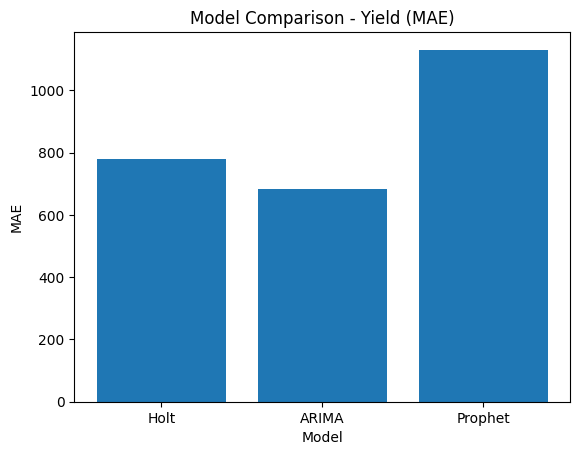

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(mae_table["Model"], mae_table["MAE_Yield"])
plt.title("Model Comparison - Yield (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

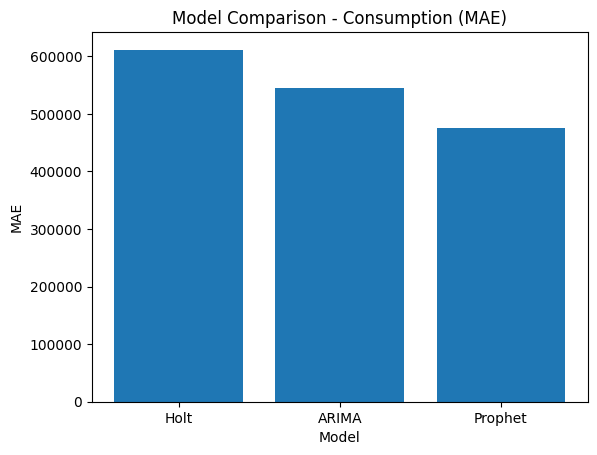

In [13]:
#Consumption MAE
plt.figure()
plt.bar(mae_table["Model"], mae_table["MAE_Consumption"])
plt.title("Model Comparison - Consumption (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()